# FSCI 396: Correlation and ANOVA

------------------
Welcome to today's tutorial! 
Today we'll use Python in Jupyter Notebook to perform some common statistical analyses.
We will cover: Correlations and ANOVA 


The goal is to see how we can analyze data with Python, just like we discussed in lectures.


### Steps to Debugging 

I am here to help you! But before you contact me, make sure you have tried the following:
1. Ensure that all brackets and parentheses are paired.
2. Ensure that your code does not have any typos (eg. when calling your data file).
3. Ensure you did not add additional spaces (eg. when calling your data file).
4. You have restarted your kernel and reun your code. 
5. You have tried to understand the error message. 

If you have done all of these things, I am very happy to help! 

In [1]:
# Import Modules
# ---------------

# Modules in Python are like library books. 
# Each book contains a set of instructions or “recipes” for doing specific tasks.
# - pandas: for handling and analyzing tables of data
# - numpy: for numerical calculations
# - seaborn & matplotlib: for making plots
# - statsmodels: for running statistical models and regression analysis
# - statsmodels.formula.api (smf): convenient formula interface
# - statsmodels.api (sm): tools for more advanced statistical modeling
# - semopy: used for structural equation modelling 

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.anova import anova_lm
import semopy

# Ignore Warnings for simplicity
import warnings
warnings.filterwarnings('ignore')

# Quick check to see if modules loaded correctly
print("Modules loaded successfully!")


Modules loaded successfully!


In [2]:
# These are the functions to calculate the values of interest for this study. 
# You do not have to touch this if you do not want to 

def Correl(df):
    table3 = df.loc[:, 'Rehearsal':'Anxiety_group'].corr()
    return table3

print('Functions have successfully been defined!')

Functions have successfully been defined!


In [3]:
# Load datafile/dataframe (df) from CSV
# --------------------------------------

# Here we load our data. Make sure the CSV file is in the same folder as this notebook.

# If your data is .csv, use these two lines: 
filename = 'SampleData.csv'    # Name of your file
df = pd.read_csv(filename)         # Read the CSV into a DataFrame

# Checkpoint to ensure the file has been loaded 
print(filename, 'has been loaded')


Anon_Compiled_Qual_2024-2025_Grades.xlsx has been loaded


In [4]:
df = df[df['Grade'].notna()]
df

,Unnamed: 0,CW1,CW2,CW3,EM1,EM2,EM3,EM4,DS1,DS2,...,State_Anxiety,SelfEfficacy,Anxiety_test,Anxiety_writing,Anxiety_speaking,Anxiety_group,semester,Course,Qual2_Anon,Qual1_Anon
0,0,6.0,6.0,6.0,2.0,2.0,1.0,4.0,6.0,6.0,...,13.050000,6.250,5.000000,5.000000,5.666667,5.666667,F24,BIOL1XX,NaN,NaN
1,1,3.0,2.0,2.0,2.0,4.0,1.0,3.0,6.0,3.0,...,9.033333,5.500,5.333333,6.666667,6.333333,6.333333,F24,BIOL1XX,NaN,NaN
2,2,6.0,4.0,5.0,4.0,6.0,1.0,5.0,2.0,2.0,...,11.200000,3.875,5.333333,5.333333,3.666667,2.000000,F24,BIOL1XX,NaN,NaN
4,4,6.0,6.0,5.0,4.0,4.0,5.0,4.0,5.0,5.0,...,14.916667,3.750,5.333333,5.000000,6.666667,5.000000,F24,BIOL1XX,NaN,NaN
6,6,6.0,7.0,7.0,7.0,7.0,7.0,7.0,4.0,2.0,...,17.466667,4.500,4.333333,3.333333,3.333333,1.333333,F24,BIOL1XX,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
901,411,2.0,6.0,5.0,5.0,5.0,2.0,5.0,2.0,3.0,...,10.983333,6.750,5.333333,2.666667,3.333333,1.000000,F25,COMP2BX,I reviewed all lectures and took practice exam...,"Prepared, but less accurately evaluated than a..."
903,413,3.0,6.0,4.0,4.0,5.0,2.0,2.0,2.0,3.0,...,10.783333,4.125,3.000000,3.333333,6.000000,3.666667,F25,COMP2BX,Did lots of practice questions. I think the ty...,"Solid, I studied a lot for it to make sure I w..."
904,414,2.0,7.0,6.0,7.0,7.0,6.0,7.0,5.0,7.0,...,17.750000,2.250,4.000000,4.666667,5.333333,4.333333,F25,COMP2BX,doing recommended excercises,"concepts are explained every quickly, I had to..."
905,415,7.0,7.0,7.0,2.0,5.0,3.0,7.0,4.0,4.0,...,15.250000,4.750,2.666667,5.666667,7.000000,5.000000,F25,COMP2BX,I felt like I had limited time to prepare. I w...,I felt like I would do terrible on it. I was u...


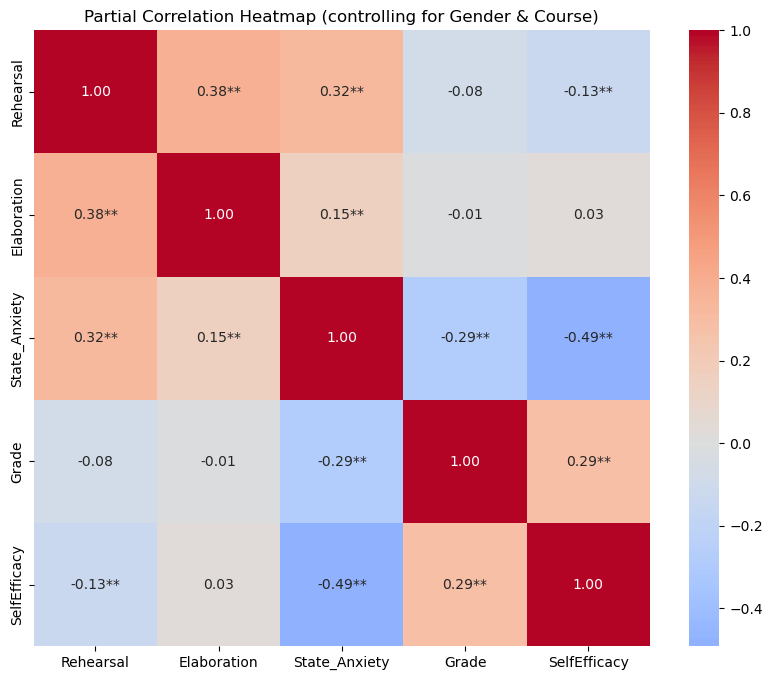

In [7]:
# import pandas as pd
import pingouin as pg
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Define the variables in the desired order
vars_ordered = ['Rehearsal', 'Elaboration', 'State_Anxiety', 'Grade', 'SelfEfficacy']

# 2. Create dummy covariates for Gender and Course
covariates = pd.get_dummies(df[['Gender','Course']], drop_first=True)

# 3. Combine numeric columns + covariates
df_numeric = pd.concat([df, covariates], axis=1)

# 4. Create empty DataFrames for r values and annotations
pcorr_matrix = pd.DataFrame(index=vars_ordered, columns=vars_ordered, dtype=float)
annot_matrix = pd.DataFrame(index=vars_ordered, columns=vars_ordered, dtype=str)

# 5. Compute partial correlations and significance
for var1 in vars_ordered:
    for var2 in vars_ordered:
        if var1 == var2:
            pcorr_matrix.loc[var1, var2] = 1.0
            annot_matrix.loc[var1, var2] = '1.00'
        else:
            result = pg.partial_corr(data=df_numeric, x=var1, y=var2, covar=covariates.columns.tolist())
            r = result['r'].values[0]
            p = result['p-val'].values[0]

            # Assign significance stars
            if p < 0.01:
                star = '**'
            elif p < 0.05:
                star = '*'
            else:
                star = ''

            pcorr_matrix.loc[var1, var2] = r
            annot_matrix.loc[var1, var2] = f'{r:.2f}{star}'

# 6. Plot the heatmap
plt.figure(figsize=(10,8))
sns.heatmap(pcorr_matrix.astype(float), annot=annot_matrix, fmt='', cmap='coolwarm', center=0, square=True)
plt.title('Partial Correlation Heatmap (controlling for Gender & Course)')
plt.savefig('PartialCorr')
plt.show()


In [6]:
import pandas as pd
import statsmodels.api as sm
import numpy as np

# Function to get residuals after controlling for covariates
def residualize(y, covariates):
    # Add constant for intercept
    X = sm.add_constant(covariates)
    model = sm.OLS(y, X).fit()
    return model.resid

# Example: get partial correlation between Rehearsal and PredictedGrade controlling for Gender & Course
covariates = pd.get_dummies(df[['Gender', 'Course']], drop_first=True)  # convert categorical to dummies

# residualize both variables
resid_rehearsal = residualize(df['Rehearsal'], covariates)
resid_grade = residualize(df['PredictedGrade'], covariates)

# correlate the residuals
partial_corr = np.corrcoef(resid_rehearsal, resid_grade)[0,1]
print('Partial correlation (controlling for Gender and Course):', partial_corr)


ValueError: Pandas data cast to numpy dtype of object. Check input data with np.asarray(data). The types seen wereNone and const                            float64
Gender_I prefer not to answer      uint8
Gender_Man                         uint8
Gender_Woman                       uint8
Course_ATOC1XX                     uint8
Course_BIOC3XX                     uint8
Course_BIOL1XX                     uint8
Course_COMP2BX                     uint8
Course_MATH2XX                     uint8
Course_MIMM2XX                     uint8
Course_PHYS1XX                     uint8
Course_PSYCH2XX                    uint8
dtype: object. The data was
0      A
1      A
2      B
4      C
6      A
      ..
901    B
903    B
904    B
905    B
907    F
Name: PredictedGrade, Length: 574, dtype: object
and
      const  Gender_I prefer not to answer  Gender_Man  Gender_Woman   \
0      1.0                              0           1              0   
1      1.0                              0           0       

# Correlations 

- **Correlation coefficient (r)** measures the strength and direction of a linear relationship between two variables.  
  *r ≈ 0 --> little or no linear relationship.* \
  *r > 0 --> positive relationship (as one variable increases, the other tends to increase).* \
  *r < 0 --> negative relationship (as one variable increases, the other tends to decrease).*   

- **Interpretation**:  
  - |r| ≈ 0.1 --> weak  
  - |r| ≈ 0.3 --> moderate  
  - |r| ≈ 0.5+ --> strong  

- **Notes**:  
  - Correlation does not imply causation.  
  - Pearson correlation assumes variables are roughly linearly related and continuous.  
  - Outliers can strongly influence r.  



In [ ]:
# Take dataframe we loaded and output the correlation table 
# The variables here have been defined for you in the functions. 
Correl(df)

In [ ]:
# Take these Correlations and plot a heatmap 
plt.figure(figsize=(6, 5)) 
sns.heatmap(Correl(df), annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)

plt.title('Complete Correlation Heatmap') 
plt.show()
plt.close()

# How to read:
    # Red indicates a positive correlation. 
    # Blue inidicates a negative corelation. 
    # The deeper/darker the colour, the stronger the correlation. 
    # The more faint/lighter the colour, the weaker the correlation.

# ANOVA (Analysis of Variance)

The ANOVA table compares group means, where each row corresponds to a given output/dependent variable. This requires some sorting/organizing to put each data point into a category. This may sound similar to regression, because ANOVA is a special case of regression. It is specifically when we categorize all input/independent/predictor variables. Regression can do this, but it does not need to group or categorize the predictor variables. 


For example, if you were to split (categorize) students into positive/neutral/negative mindsets, then look at each groups average self efficacy. The ANOVA table would produce one line that indicates how much these differ, and whether these differences are significant. Regression could predict self efficiacy without grouping them into mindset groups. 


- **Interpretation**: the sum_sq will tell you how much variance the factor explains. PR tells you if this is significant. 
    - *"sum_sq" --> Sum of Squares, total variation attributed to each source (predictor or residual).*
              *Larger values mean that the variable explains more variance in the output variable.*\
    - *"df"       --> Degrees of Freedom, number of parameters estimated for that variable.*\
    - *"F"        --> F-statistic: ratio of variance explained by the variable to unexplained (residual) variance.*\
         *High F = variable explains a large proportion of Y’s variance relative to noise.*
    - *PR(>F)   --> p-value: probability that the observed F would occur if the variable had no real effect.*\
              *Low p (< .05) → predictor significantly contributes to explaining Y.*


- **Quick Translation**

     *F and PR(>F)     --> “Does this predictor explain a significant amount of variance in Y?”*\
     *sum_sq           --> “How much variance does this predictor explain?”*\
     Residual row     --> “How much variance is left unexplained by the model?”


In [ ]:
# Categorical Analysis 

predicted = 'SelfEfficacy '
predictors = 'C(Gender)'

# Correct: no backticks needed
ANOVAmodel = smf.ols(f"{predicted} ~ {predictors}", data=df).fit()

# Run ANOVA
anova_table = sm.stats.anova_lm(ANOVAmodel, typ=2)
anova_table
